<a href="https://colab.research.google.com/github/Deveshjd/ML-Notebooks/blob/main/LinearReg1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = sns.load_dataset("mpg")

In [3]:
data.dropna(axis=0,inplace=True)

In [4]:
x = data.drop("mpg",axis=1)
y = data["mpg"]

In [5]:
x.drop(["origin", "name", "model_year"],axis=1,inplace=True)

In [6]:
x.head()

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5


In [7]:
x.corrwith(y)

,0
cylinders,-0.777618
displacement,-0.805127
horsepower,-0.778427
weight,-0.832244
acceleration,0.423329


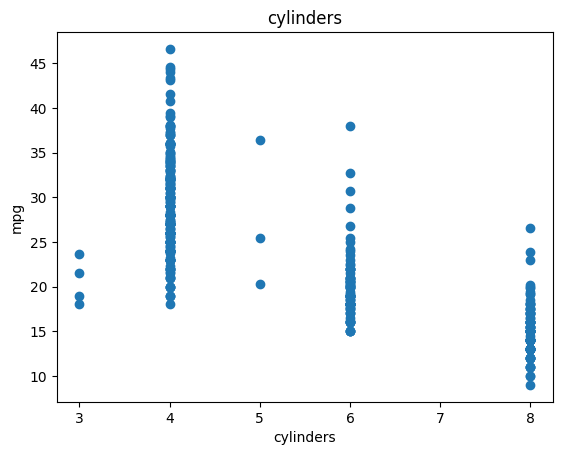

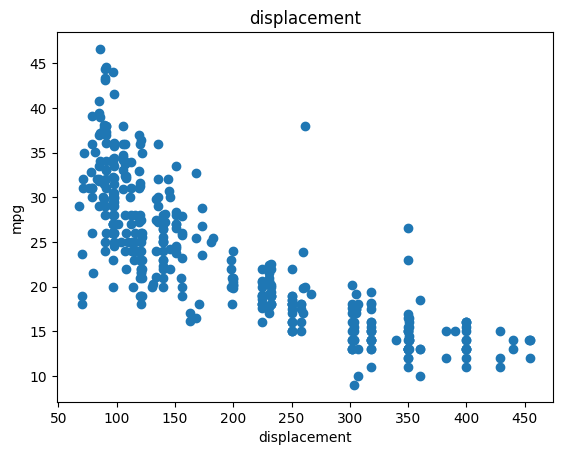

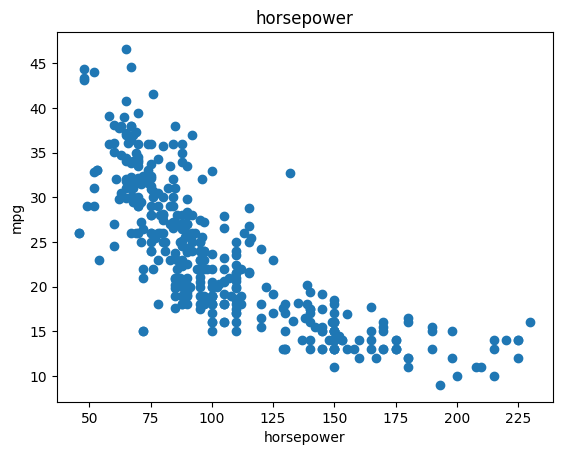

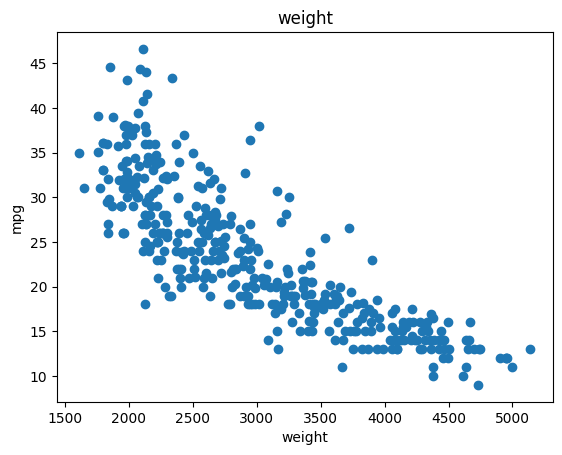

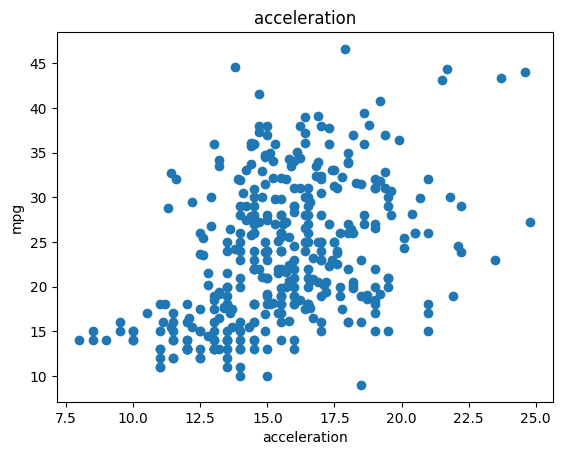

In [8]:
for i in x:
  plt.figure()
  plt.scatter(x[i],y)
  plt.title(i)
  plt.ylabel("mpg")
  plt.xlabel(i)
  plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [11]:
x_train

,cylinders,displacement,horsepower,weight,acceleration
290,8,351.0,142.0,4054,14.3
224,8,302.0,130.0,4295,14.9
94,8,440.0,215.0,4735,11.0
230,8,350.0,170.0,4165,11.4
301,4,105.0,70.0,2200,13.2
...,...,...,...,...,...
75,8,318.0,150.0,4077,14.0
312,4,86.0,65.0,2019,16.4
37,6,232.0,100.0,3288,15.5
170,4,140.0,78.0,2592,18.5


In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [13]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [14]:
y_pred = model.predict(x_test)

In [39]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("TESTING\n")
print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("R2:", r2)


y_train_pred = model.predict(x_train)
MAE_train = mean_absolute_error(y_train, y_train_pred)
MSE_train = mean_squared_error(y_train, y_train_pred)
RMSE_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("TRAINING\n")
print("MAE:", MAE_train)
print("MSE:", MSE_train)
print("RMSE:", RMSE_train)
print("R2:", r2_train)

TESTING

MAE: 3.1739744695076775
MSE: 24.556644681595778
RMSE: 4.955466141706124
R2: 0.6236035514791564


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: X has 5 features, but LinearRegression is expecting 21 features as input.

In [17]:
model.intercept_

np.float64(47.3522032498328)

In [18]:
model.coef_

array([-0.37528496, -0.00238962, -0.03993986, -0.00522688, -0.11541412])

In [19]:
x.shape

(392, 5)

In [20]:
y.shape

(392,)

In [21]:
from sklearn.preprocessing import  PolynomialFeatures

In [22]:
poly = PolynomialFeatures()
poly

PolynomialFeatures()

In [23]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

In [24]:
x_train_poly

array([[1.0000000e+00, 8.0000000e+00, 3.5100000e+02, ..., 1.6434916e+07,
        5.7972200e+04, 2.0449000e+02],
       [1.0000000e+00, 8.0000000e+00, 3.0200000e+02, ..., 1.8447025e+07,
        6.3995500e+04, 2.2201000e+02],
       [1.0000000e+00, 8.0000000e+00, 4.4000000e+02, ..., 2.2420225e+07,
        5.2085000e+04, 1.2100000e+02],
       ...,
       [1.0000000e+00, 6.0000000e+00, 2.3200000e+02, ..., 1.0810944e+07,
        5.0964000e+04, 2.4025000e+02],
       [1.0000000e+00, 4.0000000e+00, 1.4000000e+02, ..., 6.7184640e+06,
        4.7952000e+04, 3.4225000e+02],
       [1.0000000e+00, 4.0000000e+00, 8.3000000e+01, ..., 4.0120090e+06,
        3.8057000e+04, 3.6100000e+02]])

In [30]:
model = LinearRegression()
model.fit(x_train_poly,y_train)
y_pred = model.predict(x_test_poly)

In [34]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("TESTING\n")
print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("R2:", r2)

print("-"*100)
y_train_pred = model.predict(x_train)
MAE_train = mean_absolute_error(y_train, y_train_pred)
MSE_train = mean_squared_error(y_train, y_train_pred)
RMSE_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("TRAINING\n")
print("MAE:", MAE_train)
print("MSE:", MSE_train)
print("RMSE:", RMSE_train)
print("R2:", r2_train)

TESTING

MAE: 3.1739744695076775
MSE: 24.556644681595778
RMSE: 4.955466141706124
R2: 0.6236035514791564
----------------------------------------------------------------------------------------------------
TRAINING

MAE: 2.579900500836772
MSE: 11.702909879116556
RMSE: 3.420951604322481
R2: 0.8036020463271804


In [37]:
from sklearn.model_selection import cross_val_score, cross_validate

In [38]:
cv_score = cross_val_score(model, x_train_poly, y_train, cv = 10)
cv_score

array([0.85193564, 0.64197843, 0.83302075, 0.77830222, 0.75460191,
       0.66719346, 0.69059297, 0.78522207, 0.74531757, 0.79840236])